In [1]:
%load_ext autoreload
%autoreload 2
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import scipy
from scipy.interpolate import UnivariateSpline
from scipy.interpolate import interp1d
import lmfit
import ray
import os
import timeit
from spectral import BandResampler

from bio_optics.water import absorption, attenuation, backscattering, scattering, lee
from bio_optics.atmosphere import downwelling_irradiance
from bio_optics.models import hereon, model
from bio_optics.helper import resampling, utils, owt, indices, plotting
from bio_optics.water import fluorescence

In [2]:
%reload_ext autoreload

In [3]:
## check, that the correct version is loaded:
import bio_optics
bio_optics.water.__file__

'c:\\users\\dagmar\\pycharmprojects\\bio_optics\\bio_optics\\water\\__init__.py'

# Other comparisons

In [4]:
def set_default_parameters(AlgaeGroupType='Standardv3'):
    ## by Default:
    # - all Phytoplankton groups are value=0, min=0, max=1000 (C_5=10, C_7=1), vary = False
    # - C_Y value=0, min=0, max=30, vary=True
    # - C_ism value=0, min=0, max=100, vary=True
    # - fluorescence all vary = False
    # - offset vary = False
    params = lmfit.Parameters()                             # v3 ,      SummerBloom
    params.add('C_0', value=0, min=0, max=100, vary=False)  # Diatoms
    params.add('C_1', value=0, min=0, max=100, vary=False)  # green
    params.add('C_2', value=0, min=0, max=100, vary=False)  # cryptophyte
    params.add('C_3', value=0, min=0, max=100, vary=False)  # cyano blue
    params.add('C_4', value=0, min=0, max=100, vary=False)  # cyano red
    params.add('C_5', value=0, min=0, max=10, vary=False)   # coccolithophores , Phaeocystis: other ranges
    params.add('C_6', value=0, min=0, max=100, vary=False)  # dinoflagellates
    params.add('C_7', value=0, min=0, max=1, vary=False)    # case-1  , Noctiluca: other ranges
    params.add('C_Y', value=0, min=0, max=30, vary=True)
    params.add('C_ism', value=0, min=0, max=100, vary=True)
    params.add('L_fl_lambda0', value=0, min=0, max=0.2, vary=False)
    params.add('L_fl_phycocyanin', value=0, min=0, max=0.2, vary=False)
    params.add('L_fl_phycoerythrin', value=0, min=0, max=0.2, vary=False)
    params.add('b_ratio_C_0', value=0.0058, vary=False)  # Diatoms
    params.add('b_ratio_C_1', value=0.007, vary=False)  # green
    params.add('b_ratio_C_2', value=0.0042, vary=False)  # cryptophyte
    params.add('b_ratio_C_3', value=0.0082, vary=False)  # cyano blue
    params.add('b_ratio_C_4', value=0.001, vary=False)  # cyano red
    # if AlgaeGroupType == 'NSSummerBloomsv3':
    if AlgaeGroupType == 'Summer':
        params.add('b_ratio_C_5', value=0.0034, vary=False)  # Phaeocystis: change to 0.0034
    else:
        params.add('b_ratio_C_5', value=0.0129, vary=False)  # coccolithophores , Phaeocystis: change to 0.0034
    params.add('b_ratio_C_6', value=0.0209, vary=False)  # dinoflagellates
    # if AlgaeGroupType == 'NSSummerBloomsv3':
    if AlgaeGroupType == 'Summer':
        params.add('b_ratio_C_7', value=0.0209, vary=False)  # Noctiluca: change to 0.0209
    else:
        params.add('b_ratio_C_7', value=0.0109, vary=False)  # case-1 , Noctiluca: change to 0.0209
    params.add('b_ratio_md', value=0.0216, min=0.021, max=0.3756, vary=True)  # max=0.0756
    params.add('b_ratio_bd', value=0.0216, min=0.021, max=0.3756, vary=True)  # max=0.0756
    # params.add('b_ratio_d', value=0.0216, min=0.021, max=0.3756, vary=True)
    params.add('A_md', value=13.4685e-3, vary=False)
    params.add('A_bd', value=0.3893e-3, vary=False)
    params.add('S_md', value=10.3845e-3, vary=False)
    params.add('S_bd', value=15.7621e-3, vary=False)
    params.add('S_cdom', value=0.0185, min=0.005, max=0.032, vary=True) # test Baltic: min =0.01
    params.add('C_md', value=12.1700e-3, vary=False)
    params.add('C_bd', value=0.9994e-3, vary=False)
    params.add('K', value=0, min=0, vary=False)
    params.add('lambda_0_cdom', value=440, vary=False)
    params.add('lambda_0_md', value=550, vary=False)
    params.add('lambda_0_bd', value=550, vary=False)
    params.add('lambda_0_c_d', value=550, vary=False)
    params.add('lambda_0_phy', value=676, vary=False)
    params.add('gamma_d', value=0.3835, vary=False)
    params.add('x0', value=1, vary=False)
    params.add('x1', value=10, vary=False)
    params.add('x2', value=-1.3390, min=-1.3390 - 0.0618, max=-1.3390 + 0.0618, vary=False)
    params.add('A', value=0.0237, vary=False)
    params.add('E0', value=1, vary=False)
    params.add('E1', value=0.8987, vary=False)
    params.add('W', value=0.75, vary=False)
    params.add('fwhm1', value=25, vary=False)
    params.add('fwhm2', value=50, vary=False)
    params.add('fwhm_phycocyanin', value=20, vary=False)
    params.add('fwhm_phycoerythrin', value=20, vary=False)
    params.add('lambda_C1', value=685, vary=False)
    params.add('lambda_C2', value=730, vary=False)
    params.add('lambda_C_phycocyanin', value=644, vary=False)
    params.add('lambda_C_phycoerythrin', value=573, vary=False)
    params.add('double', value=True, vary=False)
    params.add('interpolate', value=True, vary=False)
    params.add("Gw0", value=0.05881474, vary=False)
    params.add("Gw1", value=0.05062697, vary=False)
    params.add("Gp0", value=0.03997009, vary=False)
    params.add("Gp1", value=0.1398902, vary=False)
    params.add('error_method', value=0, vary=False)
    params.add('theta_sun', value=np.radians(30), min=np.radians(0), max=np.radians(90), vary=False)
    params.add('theta_view', value=np.radians(1e-10), min=np.radians(1e-10), max=np.radians(90), vary=False)
    params.add('n1', value=1, vary=False)
    params.add('n2', value=1.33, vary=False)
    params.add('kappa_0', value=1.0546, vary=False)
    params.add('fresh', value=False, vary=False)
    params.add('T_W', value=25, min=0, max=40, vary=False)
    params.add('T_W_0', value=20, vary=False)
    params.add('P', value=1013.25, vary=False)
    params.add('AM', value=1, vary=False)
    params.add('RH', value=60, vary=False)
    params.add('H_oz', value=0.38, vary=False)
    params.add('WV', value=2.5, vary=False)
    params.add('alpha', value=1.317, vary=False)
    params.add('beta', value=0.2606, vary=False)
    params.add('g_dd', value=0.02, min=-1, max=10, vary=False)  # glint correction
    params.add('g_dsr', value=1 / np.pi, min=0, max=10, vary=False)  # glint correction
    params.add('g_dsa', value=1 / np.pi, min=0, max=10, vary=False)  # glint correction
    params.add('d_r', value=0, min=0, max=0.1, vary=False)
    params.add('f_dd', value=1, vary=False)
    params.add('f_ds', value=1, vary=False)
    params.add('offset', value=0, min=-0.1, max=0.1, vary=False)
    params.add('fit_surface', value=False, vary=False)
    return params


def set_parameters_byDict(pDict, params):
    for key in pDict.keys():
        thisD = pDict[key]
        params.add(key, value=thisD['value'], min=thisD['min'], max=thisD['max'], vary=True)
    return params

In [3]:
# Define wavelength range and sampling rate
wavelengths=np.arange(400,900, 5)

# Select iop-model setup!
AlgaeGroupType = 'HEREON' #'Standard' # 'Standardv2': HEREON, 'Standardv3': 'Standard', NSSummerBloomsv3': 'Summer'


# global inputs that don't change with fit params
a_md_spec_res = absorption.a_md_spec(wavelengths=wavelengths)
a_bd_spec_res = absorption.a_bd_spec(wavelengths=wavelengths)
a_w_res = resampling.resample_a_w(wavelengths=wavelengths)
if AlgaeGroupType == 'HEREON':
    a_i_spec_res = resampling.resample_a_i_spec_EnSAD(wavelengths=wavelengths) # prototype v2, PACEv2
    b_i_spec_res = resampling.resample_b_i_spec_EnSAD(wavelengths=wavelengths) # prototype v2, PACEv2
if AlgaeGroupType == 'Standard':
    a_i_spec_res = resampling.resample_a_i_spec_EnSAD_Standardv3(wavelengths=wavelengths) # prototype v3, PACEv3
    b_i_spec_res = resampling.resample_b_i_spec_EnSAD_Standardv3(wavelengths=wavelengths) # prototype v3, PACEv3
if AlgaeGroupType == 'Summer':
    a_i_spec_res = resampling.resample_a_i_spec_EnSAD_SummerBloomsv3(wavelengths=wavelengths) # prototype v3, PACEv3
    b_i_spec_res = resampling.resample_b_i_spec_EnSAD_SummerBloomsv3(wavelengths=wavelengths) # prototype v3, PACEv3
b_bw_res = backscattering.b_bw(wavelengths=wavelengths, fresh=False)

da_W_div_dT_res = resampling.resample_da_W_div_dT(wavelengths=wavelengths)
h_C_res = fluorescence.h_C_double(wavelengths=wavelengths, W=0.75)
h_C_phycocyanin_res = fluorescence.h_C(wavelengths=wavelengths, fwhm=20, lambda_C=644)
h_C_phycoerythrin_res =fluorescence.h_C(wavelengths=wavelengths, fwhm=20, lambda_C=573)
omega_d_lambda_0_res = attenuation.omega_d_lambda_0()

E_0_res = resampling.resample_E_0(wavelengths=wavelengths)
a_oz_res = resampling.resample_a_oz(wavelengths=wavelengths)
a_ox_res = resampling.resample_a_ox(wavelengths=wavelengths)
a_wv_res = resampling.resample_a_wv(wavelengths=wavelengths)
n2_res = resampling.resample_n(wavelengths=wavelengths)

E_dd_res = downwelling_irradiance.E_dd(wavelengths=wavelengths)
E_dsa_res = downwelling_irradiance.E_dsa(wavelengths=wavelengths)
E_dsr_res = downwelling_irradiance.E_dsr(wavelengths=wavelengths)
E_d_res = E_dd_res + E_dsa_res + E_dsr_res

In [29]:
# fpath = "C:\WASI6\DATA\\user\\1b.FWD" NAP as C_X, default parameters
# fpath = "C:\WASI6\DATA\\user\\1c.FWD" # NAP as Mie
fpath = "C:\WASI6\DATA\\user\\1d_Cx.FWD" # NAP as C_X, changed anap_spec, Snap, Sg
gg = pd.read_csv(fpath, sep='\t', skiprows=11, names=['wavelen', 'Rrs', ''], index_col=False)
#gg.columns.values = ['wavelen', 'Rrs']
gg

,wavelen,Rrs,
0,380.0,0.000993,NaN
1,381.0,0.001007,NaN
2,382.0,0.001022,NaN
3,383.0,0.001036,NaN
4,384.0,0.001050,NaN
...,...,...,...
616,996.0,0.000017,NaN
617,997.0,0.000017,NaN
618,998.0,0.000017,NaN
619,999.0,0.000017,NaN


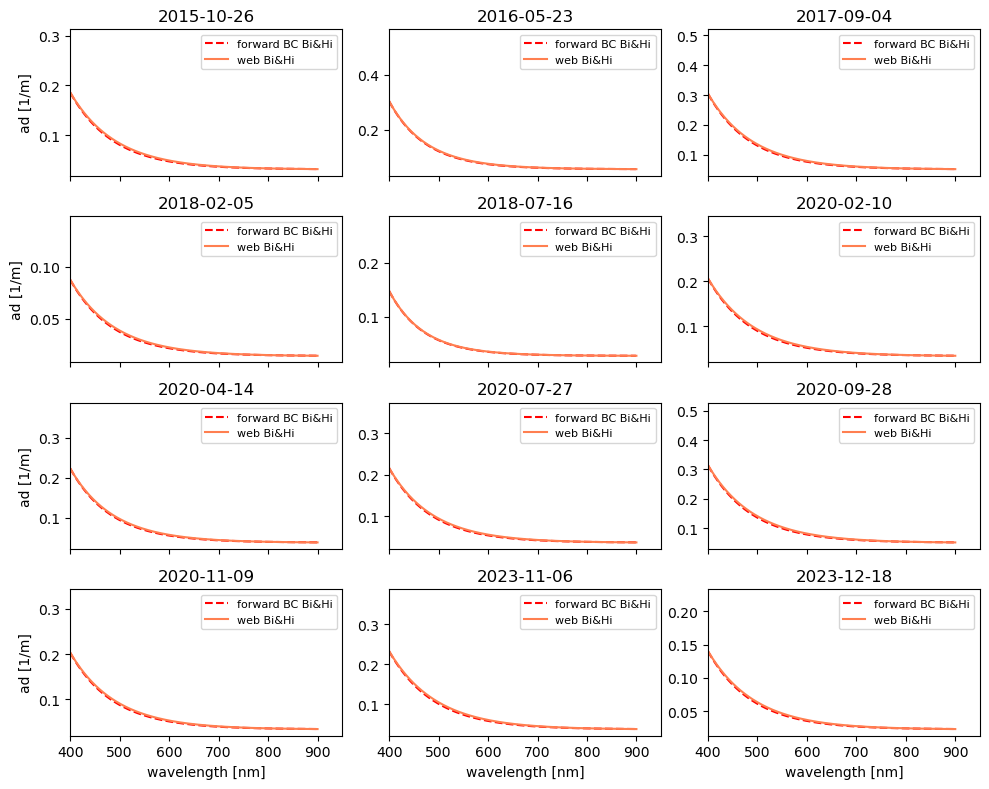

In [136]:
Nx, Ny = (3,4)
# ind = np.sort(np.random.choice(Rrs_momo.index, Nx*Ny, replace=False))
fig, ax=plt.subplots(nrows=Ny, ncols=Nx, figsize=(10,8), sharex=True, sharey=False)

VarList = ['aph','ad','acdom','bph','bd','aw','bw','ap','agp','bp','at','bt','bbph','bbd','bbp','bbw','bbt']
Var = 'ad'

if Var == 'ad' or Var == 'bd':
    anap_spec440 = np.unique(np.round(iop_insitu_sel['anap_spec(440) [m2 g-1]'].values, 5))
    S_xd = np.unique(np.round(iop_insitu_sel['Snap [1/nm]'].values, 5))
    a_md_spec_res = []
    offset_xd = 0.01231
    if len(anap_spec440)==1:
        a_md_spec_res = absorption.a_xd_spec(fw_wl, anap_spec440, S_xd, C_xd = offset_xd, lambda_0=440.)

if Var == 'aph':
    a_i_spec_res = resampling.resample_a_i_spec_EnSADandGold(wavelengths=fw_wl)

if Var == 'bph':
    b_i_spec_res = resampling.resample_b_i_spec_EnSADandGold(wavelengths=fw_wl)


for iy in range(Ny):
    for ix in range(Nx):

        if Var == 'ad':
            thisIOP = absorption.a_d(wavelengths=fw_wl, 
                                     C_ism=iop_insitu_sel['NAP [mg/l]'].loc[ind[iy*Nx+ix]], 
                                     C_phy=iop_insitu_sel['Chlg [µg/l]'].loc[ind[iy*Nx+ix]], 
                                     a_md_spec_res= a_md_spec_res
                                    )
        if Var == 'acdom':
            thisIOP = absorption.a_Y(C_Y = iop_insitu_sel['ag(440) [1/m]'].loc[ind[iy*Nx+ix]], 
                                     wavelengths = fw_wl, 
                                     S = iop_insitu_sel['Sg [1/nm]'].loc[ind[iy*Nx+ix]])
        
        if Var == 'aph':
            thisIOP = absorption.a_phy(wavelengths=fw_wl, 
                                       C_0=iop_insitu_sel['Ckie [µg/l]'].loc[ind[iy*Nx+ix]], 
                                       C_1=iop_insitu_sel['Cgr [µg/l]'].loc[ind[iy*Nx+ix]], 
                                       C_2=iop_insitu_sel['Ccry [µg/l]'].loc[ind[iy*Nx+ix]], 
                                       C_3=iop_insitu_sel['Cbl [µg/l]'].loc[ind[iy*Nx+ix]],
                                       C_4=iop_insitu_sel['Cbl2 [µg/l]'].loc[ind[iy*Nx+ix]],
                                       C_5=iop_insitu_sel['Cgold [µg/l]'].loc[ind[iy*Nx+ix]],
                                       C_6=iop_insitu_sel['Cdino [µg/l]'].loc[ind[iy*Nx+ix]],
                                       C_7=0., 
                                       a_i_spec_res=a_i_spec_res)
            thisIOP = absorption.correct_a_phy(a_phy_res=thisIOP, wavelengths=fw_wl, 
                                               C_phy=iop_insitu_sel['Chlg [µg/l]'].loc[ind[iy*Nx+ix]], 
                                               interpolate=False)
        if Var == 'bph':
            thisIOP = scattering.b_phy(wavelengths=fw_wl, 
                                       C_0=iop_insitu_sel['Ckie [µg/l]'].loc[ind[iy*Nx+ix]], 
                                       C_1=iop_insitu_sel['Cgr [µg/l]'].loc[ind[iy*Nx+ix]], 
                                       C_2=iop_insitu_sel['Ccry [µg/l]'].loc[ind[iy*Nx+ix]], 
                                       C_3=iop_insitu_sel['Cbl [µg/l]'].loc[ind[iy*Nx+ix]],
                                       C_4=iop_insitu_sel['Cbl2 [µg/l]'].loc[ind[iy*Nx+ix]],
                                       C_5=iop_insitu_sel['Cgold [µg/l]'].loc[ind[iy*Nx+ix]],
                                       C_6=iop_insitu_sel['Cdino [µg/l]'].loc[ind[iy*Nx+ix]],
                                       C_7=0., 
                                       b_i_spec_res=b_i_spec_res)
            # aphs, thisIOP = IOP_ph_B22_C2(C_0=iop_insitu_sel['Ckie [µg/l]'].loc[ind[iy*Nx+ix]], 
            #                             C_1=iop_insitu_sel['Cgr [µg/l]'].loc[ind[iy*Nx+ix]], 
            #                             C_2=iop_insitu_sel['Ccry [µg/l]'].loc[ind[iy*Nx+ix]], 
            #                             C_3=iop_insitu_sel['Cbl [µg/l]'].loc[ind[iy*Nx+ix]],
            #                             C_4=iop_insitu_sel['Cbl2 [µg/l]'].loc[ind[iy*Nx+ix]],
            #                             C_5=iop_insitu_sel['Cgold [µg/l]'].loc[ind[iy*Nx+ix]],
            #                             C_6=iop_insitu_sel['Cdino [µg/l]'].loc[ind[iy*Nx+ix]],
            #                             C_7=0., 
            #                             a_i_spec = a_i_spec_res,
            #                             c_i_spec = cphs_i_spec,
            #                             wavelen = fw_wl)
        if Var == 'bd':
            a_d_res = absorption.a_d(wavelengths=fw_wl, 
                                     C_ism=iop_insitu_sel['NAP [mg/l]'].loc[ind[iy*Nx+ix]], 
                                     C_phy=iop_insitu_sel['Chlg [µg/l]'].loc[ind[iy*Nx+ix]], 
                                     a_md_spec_res= a_md_spec_res
                                    )
            c_d_res = attenuation.c_d(wavelengths=fw_wl, 
                                  C_phy=iop_insitu_sel['Chlg [µg/l]'].loc[ind[iy*Nx+ix]], 
                                  C_ism=iop_insitu_sel['NAP [mg/l]'].loc[ind[iy*Nx+ix]], 
                                  a_md_spec_res=a_md_spec_res)
            thisIOP = c_d_res - a_d_res
        
        ax[iy, ix].plot(fw_wl, thisIOP, 'r--', label='forward BC Bi&Hi')
        
        d = biDict[str(ind[iy*Nx+ix]).split('T')[0]]
        ax[iy, ix].plot(d['wavelen'].values, d[Var].values, '-', color='coral', label='web Bi&Hi')

        # band_resampler = BandResampler(d.wavelen.values, fw_wl) 
        # bi_iop = band_resampler(np.asarray(d[Var].values))
        # ID = fw_wl > 800.
        # perc = np.percentile((bi_iop[ID] - thisIOP[ID])/iop_insitu_sel['NAP [mg/l]'].loc[ind[iy*Nx+ix]], [5, 50, 95])
        # print("Diff", Var, perc)
        
        # ax[iy, ix].set_title(str(ind[iy*Nx+ix]).split('T')[0] + ' NAP:' + str(np.round(iop_insitu_sel['NAP [mg/l]'].loc[ind[iy*Nx+ix]], 2)))
        ax[iy, ix].legend(fontsize=8)
        ax[iy, ix].set_xlim((400, 950))
        ax[iy, ix].set_title(str(ind[iy*Nx+ix]).split('T')[0])
        if Var == 'acdom':
            ax[iy,ix].set_ylim((0,1))
        if iy == Ny-1:
            ax[iy, ix].set_xlabel('wavelength [nm]')
        if ix == 0:
            ax[iy, ix].set_ylabel(Var + ' [1/m]')


fig.tight_layout()
plt.show()

In [76]:
path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\consistency\webHEREON\\forPhytoAttenuation\\"
fnames = os.listdir(path)

c_bi_Dict={}
for fn in fnames:
    b = pd.read_csv(path + fn, header=0)
    phyto = fn.split('_')[-1].split('.')[0]
    c_bi_Dict[phyto[:-1]] = b

Brown [0.2220461  0.2307279  0.24704918]
Green [0.22805344 0.22805344 0.22805344]
Crypto [0.19916667 0.19916667 0.19916667]
CyanoB [0.239 0.239 0.239]
CyanoR [0.239 0.239 0.239]
Gold [0.19916667 0.19916667 0.19916667]
Dino [0.2220461  0.2307279  0.24704918]
Case1 [0.12556006 0.15814071 0.23754213]


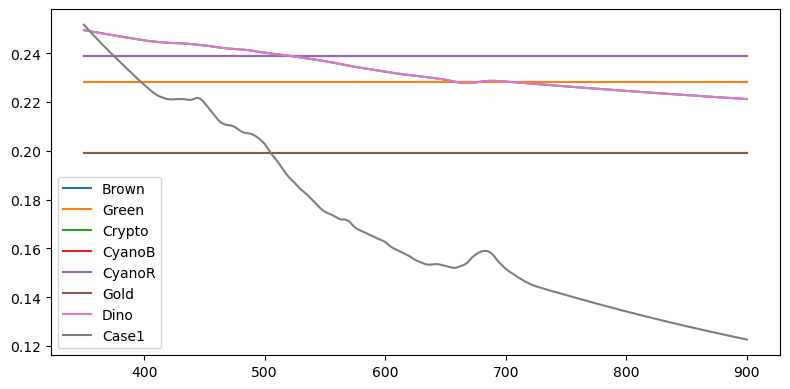

In [86]:
fig, ax = plt.subplots(figsize=(8,4))
# colList = ['Brown', 'Green', 'Crypto', 'CyanoB', 'CyanoR', 'Coccol', 'Case1'] # Bi&Hieronymi web-Version
colList = ['Brown', 'Green', 'Crypto', 'CyanoB', 'CyanoR', 'Gold', 'Dino', 'Case1'] # EnsADGold 
outDF = pd.DataFrame()
for key in colList: #c_bi_Dict.keys():
    key_ = key
    if key == 'Gold':
        key_ = 'Crypto'
    elif key == 'Dino':
        key_ = 'Brown'
    b = c_bi_Dict[key_]
    print(key, np.percentile(b['aph']+b['bph'], [5, 50, 95]))
    ax.plot(b['wavelen'], b['aph']+b['bph'], '-', label=key)
    if len(outDF) == 0:
        outDF['wavelen'] = b['wavelen'].values
    outDF[key] = b['aph'].values+b['bph'].values
ax.legend()
# ax.set_ylim((0.18, 0.28))
fig.tight_layout()
plt.show()

outpath = "C:\\Users\Dagmar\PycharmProjects\\bio_optics\\bio_optics\\data\\"
# outDF.to_csv(outpath + 'c_phy_spec_Bi.txt', header=True, index=False)
outDF.to_csv(outpath + 'c_phy_spec_EnsADGold.txt', header=True, index=False)
## add dinoflagellates -> brown. Goldalgae -> crypto. Setup for the different group sets.

In [117]:
def calc_aph676(Chl, varyA = False):

  A    = 0.0239
  A_sd = 0.1
  A_up = 0.0501
  A_lo = 0.0112
  E    = 0.8938

  if (varyA):
    A = 10 ** rnorm_bound( 1,
      mean = log10(A),
      sd = A_sd,
      up = log10(A_up),
      lo = log10(A_lo)
    )
  
  # split them in two Chl ranges
  r1 = A * Chl**1 # linear Chl <  1
  r2 = A * Chl**E # powerl Chl >= 1
  r = r1
  w = np.array(Chl >= 1)
  r[w] = r2[w]

  # attr(r, "A_aphs676") <- A
  # attr(r, "E_aphs676") <- E
  # attr(r, "varyA") <- varyA

  # class(r) <- "Hereon_aphs_func"

  return r

def generate_aphs(Chl,
                  a_i_spec = [],
                c_i_spec = [],
                 lambda_0_phy = 676.,
                # albedo_ph676=[0.8952, 0.8952, 0.8800, 0.9000, 0.9000, 0.9562, 0.8485], # Bi web-Version
                 albedo_ph676=np.asarray([0.8952, 0.8952, 0.8800, 0.9000, 0.9000,  0.8800, 0.8952, 0.8485]) , # EnsADGold
                  # gamma_ph676=[np.nan, 0.00, 0.00, 0.00, 0.00, np.nan, np.nan] # Bi web-Vserion
                 gamma_ph676=np.asarray([np.nan, 0.00, 0.00, 0.00, 0.00, np.nan, np.nan, np.nan]), # EnsADGold
                 
                  a_frac = np.array([1, 1, 1, 1, 1, 1, 1, 1]),
                wavelengths= np.arange(400., 800.)):

    # Some albedo reference
    # Figure 8 (w532) of Nardelli, Schuyler C., and Michael S. Twardowski. “Assessing the
    # Link between Chlorophyll Concentration and Absorption Line Height at 676 Nm
    # over a Broad Range of Water Types.” Optics Express 24, no. 22 (October 31,
    # 2016): A1374. https://doi.org/10.1364/OE.24.0A1374.
    
    
    # 1. [Chl] -> aphs676
    # 2. [albedo] -> cphs676
    # 3. [Normalized aphs and cphs] -> bphs


    # determine aph676 from the input function
    aph676 = calc_aph676(Chl)

    # if ("Hereon_aphs_func" %in% class(aph676)) {
    #   attr_aph676 <- attributes(aph676)
    # } else {
    #   attr_aph676 <- list(aphs_fun)
    # }
    
    aphs_676_new = aph676 / Chl
    aphs_676_new[Chl == 0] = 1.
    print(aphs_676_new)
    
    aphs_676 = a_i_spec[utils.find_closest(wavelengths, lambda_0_phy)[1]]
    aphs_mat_new = a_i_spec.copy()
    for i in range(aphs_mat_new.shape[1]):
        aphs_mat_new[:, i] = aphs_mat_new[:, i] / aphs_676[i] * aphs_676_new[i]


    cphs_676 = c_i_spec[utils.find_closest(wavelengths, lambda_0_phy)[1]]
    cphs_mat_norm = c_i_spec.copy()
    for i in range(cphs_mat_norm.shape[1]):
        cphs_mat_norm[i,:] /= cphs_676[i]  # normalized at cph676 - shape
    
    # Find group to be changed for the shape
    PG_TBC = [i for i, val in enumerate(gamma_ph676) if not np.isnan(val)]
    for i in PG_TBC:
        cphs_mat_norm[:, i] = (676. / wavelengths) ** gamma_ph676[i]
    
    coef_lin = aphs_676_new / (1. - albedo_ph676) # the coefficients in Eq 16 - magnitude
    cphs_mat_new = cphs_mat_norm.copy()
    for i in range(cphs_mat_new.shape[1]):
        cphs_mat_new[:,i] *= coef_lin[i]
        
    bphs_mat_new = cphs_mat_new - aphs_mat_new
    
    # assumption for reducing cell absorption (e.g. PIC bloom)
    for i in range(cphs_mat_new.shape[1]):
        aphs_mat_new[:, i] *= a_frac[i]
        
    cphs_mat_new <- aphs_mat_new + bphs_mat_new # compensate attenuation back

    return aphs_mat_new, bphs_mat_new, cphs_mat_new

    # aphs <- data.table(wv = phytodive_iop_list$aphs$wv, aphs_mat_new)
    # bphs <- data.table(wv = phytodive_iop_list$bphs$wv, bphs_mat_new)
    # cphs <- data.table(wv = phytodive_iop_list$cphs$wv, cphs_mat_new)
    
    # r <- list(aphs = aphs,
    #         bphs = bphs,
    #         cphs = cphs)
    
    # parm <- list(
    # aph676       =  aph676,
    # albedo_ph676 =  albedo_ph676,
    # gamma_ph676  =  gamma_ph676,
    # vary_cph     =  vary_cph,
    # a_frac       =  a_frac
    # )
    
    # attr(r, "parm") <- parm
    
    # attr(r, "attr_aph676") <- attr_aph676

In [ ]:
def b_ph_web(c_phy_spec, 
             C_0 = 0,
          C_1 = 0,
          C_2 = 0,
          C_3 = 0,
          C_4 = 0,
          C_5 = 0,
          C_6 = 0,
          C_7 = 0,
          a_phy_spec = [], # corrected total a_phy
          aph_i_spec = [],   
          wavelengths = np.arange(400,800),
             lambda_0_phy = 676.,
            # albedo_ph676=[0.8952, 0.8952, 0.8800, 0.9000, 0.9000, 0.9562, 0.8485], # Bi web-Version
             albedo_ph676=[0.8952, 0.8952, 0.8800, 0.9000, 0.9000,  0.8800, 0.8952, 0.8485] , # EnsADGold
              # gamma_ph676=[np.nan, 0.00, 0.00, 0.00, 0.00, np.nan, np.nan] # Bi web-Vserion
             gamma_ph676=[np.nan, 0.00, 0.00, 0.00, 0.00, np.nan, np.nan, np.nan] # EnsADGold
            ):

    C_i = np.array([C_0,C_1,C_2,C_3,C_4,C_5,C_6,C_7])
   
    
    ## web-Version:
    C_sum = np.sum(C_i)
    frac_C = np.zeros(len(C_i))
    if C_sum > 0:
        frac_C = C_i / C_sum
    
    a_phy_res = a_phy_spec / C_sum
    a_phy_lambda_0 = a_phy_res[utils.find_closest(wavelengths, lambda_0_phy)[1]]
    print(a_phy_lambda_0)

    # Determine aph676 from the input function
    # aph676 = aphs_fun(Chl, **kwargs)
    #
    # if hasattr(aph676, '__class__') and "Hereon_aphs_func" in aph676.__class__.__name__:
    #     attr_aph676 = getattr(aph676, '__dict__', {})
    # else:
    #     attr_aph676 = [aphs_fun]
    #
    # aphs_676_new = aph676 / Chl if Chl != 0 else 1
    #
    aphs_mat = aph_i_spec
    aphs_676 = aph_i_spec[utils.find_closest(wavelengths, lambda_0_phy)[1]].values.flatten()
    # aphs_mat_norm = aphs_mat / vec_to_mat(aphs_676, n=aphs_mat.shape[0])
    # aphs_mat_new = aphs_mat_norm * aphs_676_new

    # cphs_mat = c_phy_spec.iloc[:, 1:].to_numpy()
    ID_676 = utils.find_closest(wavelengths, lambda_0_phy)[1] # or closest to 676!
    cphs_676 = c_phy_spec[ID_676,:].flatten()
    cphs_mat_norm = c_phy_spec.copy()
    for i in range(cphs_mat_norm.shape[1]): cphs_mat_norm[:, i] /= cphs_676[i]

    PG_TBC = [i for i, val in enumerate(gamma_ph676) if not np.isnan(val)]
    for i in PG_TBC:
        cphs_mat_norm[:, i] = (676. / wavelengths) ** gamma_ph676[i]

    coef_lin = a_phy_lambda_0 / (1 - np.array(albedo_ph676))
    cphs_mat_new = cphs_mat_norm * vec_to_mat(coef_lin, n=cphs_mat.shape[0], by=1)
    bphs_mat_new = cphs_mat_new - aphs_mat_new

    aphs_mat_new = aphs_mat_new * vec_to_mat(a_frac, n=aphs_mat_new.shape[0], by=1)
    cphs_mat_new = aphs_mat_new + bphs_mat_new

    bphs = pd.DataFrame(np.column_stack((phytodive_iop_list['bphs']['wv'], bphs_mat_new)),
                        columns=phytodive_iop_list['bphs'].columns)


    return r

[3.468e+00 3.700e-02 3.310e-01 4.200e-02 0.000e+00 6.400e-02 1.000e-03
 0.000e+00]
[0.02094333 0.0239     0.0239     0.0239     1.         0.0239
 0.0239     1.        ]


C:\Users\Dagmar\AppData\Local\Temp\ipykernel_23152\3577271456.py:65: RuntimeWarning: invalid value encountered in divide
  aphs_676_new = aph676 / Chl


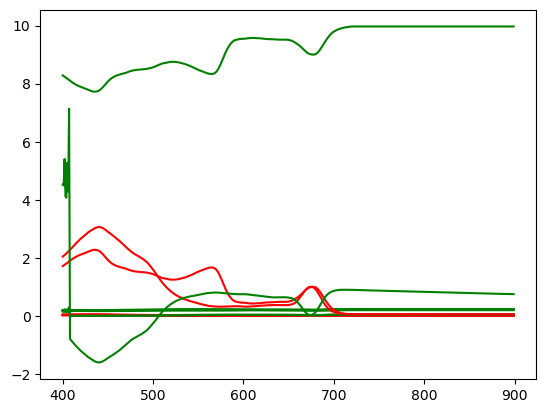

In [119]:
outpath = "C:\\Users\Dagmar\PycharmProjects\\bio_optics\\bio_optics\\data\\"
cphs = pd.read_csv(outpath + 'c_phy_spec_EnsADGold.txt', header=0)
# resample
band_resampler = BandResampler(cphs.wavelen.values, fw_wl) 
cphs_i_spec = band_resampler(np.asarray(cphs.values)[:,1:])

iy = 0
ix = 0
C_0=iop_insitu_sel['Ckie [µg/l]'].loc[ind[iy*Nx+ix]]
C_1=iop_insitu_sel['Cgr [µg/l]'].loc[ind[iy*Nx+ix]] 
C_2=iop_insitu_sel['Ccry [µg/l]'].loc[ind[iy*Nx+ix]] 
C_3=iop_insitu_sel['Cbl [µg/l]'].loc[ind[iy*Nx+ix]]
C_4=iop_insitu_sel['Cbl2 [µg/l]'].loc[ind[iy*Nx+ix]]
C_5=iop_insitu_sel['Cgold [µg/l]'].loc[ind[iy*Nx+ix]]
C_6=iop_insitu_sel['Cdino [µg/l]'].loc[ind[iy*Nx+ix]]
C_7=0.
C_i = np.array([C_0,C_1,C_2,C_3,C_4,C_5,C_6,C_7])
print(np.round(C_i, 3))

aph, bph = IOP_ph_B22_C2(C_0=iop_insitu_sel['Ckie [µg/l]'].loc[ind[iy*Nx+ix]], 
                           C_1=iop_insitu_sel['Cgr [µg/l]'].loc[ind[iy*Nx+ix]], 
                           C_2=iop_insitu_sel['Ccry [µg/l]'].loc[ind[iy*Nx+ix]], 
                           C_3=iop_insitu_sel['Cbl [µg/l]'].loc[ind[iy*Nx+ix]],
                           C_4=iop_insitu_sel['Cbl2 [µg/l]'].loc[ind[iy*Nx+ix]],
                           C_5=iop_insitu_sel['Cgold [µg/l]'].loc[ind[iy*Nx+ix]],
                           C_6=iop_insitu_sel['Cdino [µg/l]'].loc[ind[iy*Nx+ix]],
                           C_7=0., 
                  a_i_spec = a_i_spec_res,
                c_i_spec = cphs_i_spec,
          wavelen = fw_wl)


array([[0.03394696, 0.02421818, 0.02673526, ..., 0.02978678, 0.055971  ,
        0.04884668],
       [0.03431994, 0.02440274, 0.02697784, ..., 0.03010771, 0.055975  ,
        0.04944208],
       [0.03469291, 0.0245873 , 0.02722042, ..., 0.03042864, 0.055979  ,
        0.05003748],
       ...,
       [0.00086618, 0.00094715, 0.00087481, ..., 0.00017514, 0.        ,
        0.0014334 ],
       [0.00086618, 0.00094715, 0.00087481, ..., 0.00017514, 0.        ,
        0.0014334 ],
       [0.00086618, 0.00094715, 0.00087481, ..., 0.00017514, 0.        ,
        0.0014334 ]])

In [113]:
def IOP_ph_B22_C2(C_0 = 0,
          C_1 = 0,
          C_2 = 0,
          C_3 = 0,
          C_4 = 0,
          C_5 = 0,
          C_6 = 0,
          C_7 = 0,
                  a_i_spec = [],
                c_i_spec = [],
          wavelen = np.arange(400., 800.)):

    C_i = np.array([C_0,C_1,C_2,C_3,C_4,C_5,C_6,C_7])
    Chl_sum = np.sum(C_i)
    frac_phyto = C_i / Chl_sum
    
    aphs, bphs, cphs = generate_aphs(C_i, a_i_spec = a_i_spec,
                c_i_spec = c_i_spec, wavelengths = wavelen)

    for i in range(aphs.shape[1]):
        plt.plot(wavelen, aphs[:, i], 'r-')
        plt.plot(wavelen, bphs[:, i], 'g-')
    plt.show()
    
    aphs_ = aphs.copy()
    bphs_ = bphs.copy()
    for i in range(aphs.shape[1]):
        aphs_ *= frac_phyto[i]
        bphs_ *= frac_phyto[i]
    
    aphs_sum = np.sum(aphs_, axis=1)
    bphs_sum = np.sum(bphs_, axis=1)
    cphs_sum = aphs_sum + bphs_sum
    
    aph = Chl_sum * aphs_sum
    bph = Chl_sum * bphs_sum
    cph = Chl_sum * cphs_sum
    return aph, bph

In [5]:
from scipy.interpolate import make_smoothing_spline
def splineFit(X, Y, x_=None, delta=1, lam=0, ax=None, color=None, marker='-', logY=False):
    if logY:
        ID = Y == 0
        Y[ID] = np.max(Y) * 0.001
        spl = make_smoothing_spline(X, np.log10(Y), lam=lam)
    else:
        spl = make_smoothing_spline(X, Y, lam=lam)

    if x_ is None:
        x_ = np.arange(np.min(X), np.max(X)+delta, delta)
    y_ = spl(x_)
    if logY:
        y_ = 10**y_
    
    if not ax is None:
        ax.plot(x_, y_, marker, color=color)

    return x_, y_

# CHIME SNR - Model 2  
Signal-to-noise is defined on radiances at top of atmosphere.  
<!-- Our simulation data are reflectances at bottom of atmosphere.   -->
MOMO simulations include TOA radiance, so it is possible to have an estimate of the error for the different wavelengths at TOA radiance.  
We can use the MOMO simulations to calculate the impact on the reflectance under perfect conditions!  

see: Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\AQUATIME_Overview_Simulation_Inversion_20260331.pptx  


## Read CHIME SNR and Reference

In [2]:
pathSNR = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\CHIME_SNR\\"

SNR = pd.read_csv(pathSNR + "SNR_g_No_coeff.csv", header=0)
Ref = pd.read_csv(pathSNR + "SSRD_AD11 CHIME radiance levels v4.csv", header=0)


In [5]:
Ref

,wavelength (nm),Lmin (W/sr/m2/micron),Lref_L ((W/sr/m2/micron)),Lmax (W/sr/m2/micron)
0,400,57.200,139.90000,576.900
1,401,55.610,137.30000,563.500
2,402,55.560,140.80000,566.600
3,403,53.920,134.90000,553.500
4,404,53.750,121.80000,555.500
...,...,...,...,...
2096,2496,0.004,0.01901,0.322
2097,2497,0.004,0.03225,0.322
2098,2498,0.004,0.06649,0.322
2099,2499,0.004,0.03668,0.390


In [6]:
SNR

,Wavelength [nm],g,N0
0,404.2,298.624928,1.477043
1,412.6,340.045687,1.139124
2,421.0,359.345786,1.020047
3,429.4,362.448827,1.007215
4,437.8,397.359474,0.868355
...,...,...,...
245,2462.2,69.403332,8.525178
246,2470.6,48.706035,17.310059
247,2479.0,32.256519,39.466544
248,2487.4,13.538347,224.043744


## Read insitu and simulation data

In [7]:
metaDict = {
    'dalaro-2': {'project': 'AQUATIME',
        'path' : "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\dalaro-2\\",
        'datasetName': 'CHIME_sim_AQUATIME_dalaro-2',
        'iop_path': 'Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\IOPs\Case Study 2 - Dalarö\\',
        'datasetNameIOP': 'dalaro_dalaro_v0.3_daily',
        'lat': 59.128,
        'lon': 18.411,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREONgold'
                 },
    'pyhajarvi': {'project': 'AQUATIME',
        'path' : "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\pyhajarvi\\",
        'datasetName' :'CHIME_sim_AQUATIME_pyhajarvi',
        'iop_path': 'Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\IOPs\Case Study 3 pyhajarvi\\',
        'datasetNameIOP': 'pyhajarvi_continuous_v0.3',
        'lat': 61.025460552597494,
        'lon': 22.205154164905377,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREON'
                  },
    'elbe_bunthaus' : {'project': 'AQUATIME',
        'path': "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\elbe_bunthaus\\",
        'datasetName' : 'CHIME_sim_AQUATIME_elbe_bunthaus',
        'iop_path': 'Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\IOPs\Case Study 3 elbe_bunthaus\\',
        'datasetNameIOP': 'elbe-river_bunthaus_v0.3',
        'lat': 53.461787,
        'lon': 10.064451,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREON'
                       },
    'elbe_seemannshöft' :{'project': 'AQUATIME',
        'path': "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\elbe_seemannshöft\\",
        'datasetName': 'CHIME_sim_AQUATIME_elbe-seemannshöft',
        'iop_path': 'Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\IOPs\Case Study 3 elbe_seemannshöft\\',
        'datasetNameIOP': 'elbe-river_seemannshöft_v0.3',
        'lat': 53.540068,
        'lon': 9.885823,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREON'
                           },
    'oder_frankfurt': {'project': 'AQUATIME',
        'path': "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\oder_frankfurt\\",
        'datasetName': 'CHIME_sim_AQUATIME_oder_frankfurt',
        'iop_path': 'Z:\projects\\ongoing\AQUATIME\\sharepoint\WP2 Representative Dataset\\RTM_simulations\IOPs\Case Study 3 Oder_Frankfurt\\',
        'datasetNameIOP': 'oder-river_frankfurt_v0.3',
        'lat': 52.357381058811875,
        'lon': 14.55155726803013,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREON'
                       },
    'oder_hohenwutzen': { 'project': 'AQUATIME',
        'path': "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\oder_hohenwutzen\\",
        'datasetName': 'CHIME_sim_AQUATIME_oder_hohenwutzen',
        'iop_path': 'Z:\projects\\ongoing\AQUATIME\\sharepoint\WP2 Representative Dataset\\RTM_simulations\IOPs\Case Study 3 Oder_Hohenwutzen\\',
        'datasetNameIOP': 'oder-river_hohenwutzen_v0.3',
        'lat': 52.83612915898216,
        'lon': 14.122788786414537,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREON'
                         },
    'vortsjarv': {# no inversion available yet!
        'project': 'AQUATIME',
        'path' : "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\vortsjarv\\",
        'datasetName' :'CHIME_sim_AQUATIME_vortsjarv',
        'iop_path': 'Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\IOPs\Case Study 3 Vörtsjärv\\',
        'datasetNameIOP': 'vortsjarv',
        'lat': 58.2111,
        'lon': 26.10556,
        'specNAP_variable': True,
        'PhytoGroupSet' : 'HEREONgold'
    },
    'uto' : { 'project': 'AQUATIME',
        'path' : "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\\uto\\",
        'datasetName' :'CHIME_sim_AQUATIME_uto',
        'iop_path': 'Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\IOPs\Case Study 4 Utö\\',
        'datasetNameIOP': 'uto_continuous_v0.3',
        'lat': 59.7788,
        'lon': 21.3558,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREONgold'},
    'malaren' : { 'project': 'AQUATIME',
        'path' : "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\malaren-gorvaln\\",
        'datasetName' :'CHIME_sim_AQUATIME_malaren',
        'iop_path': 'Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\IOPs\Case Study 3 Mälären\\',
        'datasetNameIOP': 'malaren_gorvaln_daily_v0.3',
        'lat': 59.4321,
        'lon': 17.76425,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREONgold'
    },
    'belgian_coast_RT1': { 'project': 'AQUATIME',
        'lat': 51.2464,
        'lon': 2.9193
       },
    'belgian_coast_CPOWER': { 'project': 'AQUATIME',
        'lat': 51.532,
        'lon': 2.955
    },
    'Helsinki_SS': {'project': 'HEATWISE',
        'path': "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\helsinki_siljaserenade\\",
        'datasetName': '',
        'iop_path': "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\Helsinki\input_simulations\\",
        'datasetNameIOP': "helsinki_silja_serenade_IOP_v0.2", # 'helsinki_silja_serenade_daily_v0.3',
        'lat': 60.15,
        'lon': 25.00,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREON',
        'versionNumber': 'v0.4.1'
    },
    'Helsinki_FM': { 'project': 'HEATWISE',
        'path': "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\helsinki_finnmaid\\",
        'datasetName': '',
        'iop_path': "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\Helsinki\input_simulations\\",
        'datasetNameIOP': 'helsinki_finnmaid_daily_v0.3',
        'lat': 60.19,
        'lon': 25.213,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREON',
        'versionNumber': 'v0.3.1'
    },
    'muggelsee': { 'project': 'HEATWISE',
        'path' : "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\\berlin_muggelsee\\",
        'iop_path': "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\Muggelsee - Berlin\input_simulations\\",
        'datasetNameIOP': "berlin_muggelsee_IOP_daily_v0.3.", #"berlin_muggelsee_IOP_daily_v0.3_SZA_Gx_OZA2"
        'lat': 52.4373,
        'lon': 13.6474,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREONgold',
        'versionNumber': 'v2.0'  # something is wrong with version v0.3.0!
        }
}

### Read MOMO for noise estimation

In [8]:
# versionNumber = 'v0.3.1' # helsinki: v1.0, mueggelsee-berlin: default: v0.2 - updated MOMO model
# regionName = 'vortsjarv'

# aquatimeList = ['dalaro-2', 'elbe_bunthaus', 'elbe_seemannshöft', 'oder_frankfurt', 'oder_hohenwutzen', 'malaren-gorvaln', 'pyhajarvi', 'uto', 'vortsjarv']
# regionName = aquatimeList[4]
heatwiseList = ['muggelsee', 'Helsinki_FM', 'Helsinki_SS']
regionName = heatwiseList[0]
print(regionName)


# if regionName == "helsinki_silja_serenade": ## Rrs is wrong here!
#     path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\helsinki_siljaserenade\\"
# if regionName == 'finnmaid-helsinki':
#     path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\helsinki_finnmaid\\"
if regionName == 'Mueggelsee':
    path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\\berlin_muggelsee\\"

path = metaDict[regionName]['path']
versionNumber = 'v0.3.1'
if metaDict[regionName]['project']=='HEATWISE':
    versionNumber = metaDict[regionName]['versionNumber']

fnames = os.listdir(path)
fnameLsur = [fn for fn in fnames if 'rad-up-sur' in fn and versionNumber in fn][0]
fnameLtoa = [fn for fn in fnames if 'rad-up-toa' in fn and versionNumber in fn][0]
fnameRrs = [fn for fn in fnames if 'Rrs_' in fn and versionNumber in fn][0] # WRONG??
fnameEd = [fn for fn in fnames if 'irr-dn-sur' in fn and versionNumber in fn][0]
fnameEdir = [fn for fn in fnames if 'irr-dn-vec-sur' in fn and versionNumber in fn][0]

print(fnameLsur)
print(fnameLtoa)
print(fnameRrs)
print(fnameEd)
print(fnameEdir)

def read_MOMO_data(path, fname):
    L = pd.read_csv(path + fname, header=0)
    L['date'] = pd.to_datetime(L['date'])
    L = L.set_index('date')
    return L

Rrs = read_MOMO_data(path, fnameRrs)
varList = ['AVW', 'Area', 'NDI', 'OWT', 'membSum', 'QWIP']
for v in varList:
    if v in Rrs.columns.values:
        Rrs = Rrs.drop(columns=[v])
Ltoa = read_MOMO_data(path, fnameLtoa)
Lsur = read_MOMO_data(path, fnameLsur)
Ed = read_MOMO_data(path, fnameEd)
Edir = read_MOMO_data(path, fnameEdir)

Rrs_test = Lsur / (Ed + Edir)

wl = np.asarray([float(a) for a in Lsur.columns.values])
wlstr = [str(a) for a in wl]

## total transmission in MOMO
# t_tot = Lsur/Ltoa # version 1: WRONG
t_tot = 0.1 * Ltoa/Lsur # version 2: Ltoa = Lpath + t Lsurf = 0.9 Ltoa + t Lsurf ...

## build Ltoa / Lref 
# select Lref at the MOMO wavelengths
## MOMO-factor ##
MOMOfac = 1000./1.
ID = [np.argwhere(a == Ref.iloc[:,0].values).flatten()[0] for a in wl]
L_Lref = Ltoa.copy()*MOMOfac
for i in range(L_Lref.shape[0]):
    L_Lref.iloc[i,:] = L_Lref.iloc[i,:]/ Ref.iloc[ID, 2].values

muggelsee
HEATWISE_D2.1.0_RD-muggelsee-berlin-chime-simulated-5nm-rad-up-sur_v2.0.csv
HEATWISE_D2.1.0_RD-muggelsee-berlin-chime-simulated-5nm-rad-up-toa_v2.0.csv
HEATWISE_D2.1.0_RD-muggelsee-berlin-chime-simulated-5nm-Rrs_v2.0.csv
HEATWISE_D2.1.0_RD-muggelsee-berlin-chime-simulated-5nm-irr-dn-sur_v2.0.csv
HEATWISE_D2.1.0_RD-muggelsee-berlin-chime-simulated-5nm-irr-dn-vec-sur_v2.0.csv


### Read Bi&Hi simulations
HERE: they are modelled at CHIME bands!

In [11]:
## BC Bi&Hieronymi forward simulations
## these can have CHIME wavelengths!!
projectName =metaDict[regionName]['project']

if projectName == 'HEATWISE':
    fwpath = "Z:\projects\\ongoing\HEATWISE\\sharepoint\WP2_workspace\Water Quality\FullInversion\\bio-optics_forward\\"
elif projectName == 'AQUATIME':
    fwpath ="Z:\projects\\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\FullInversion\\bio-optics_forward\\"
iop_path = metaDict[regionName]['iop_path']

fnames = os.listdir(fwpath)
# fnames = [fn for fn in fnames if fn.startswith('SimRrs') and regionName.split('_')[0] in fn and regionName.split('_')[1] in fn]
fnames = [fn for fn in fnames if fn.startswith('SimRrs') and regionName in fn and 'CHIME' in fn] # CHIME bands!
print(fnames)
# # fname = "SimRrs_InsituForward_HEREONorig_HEREONgoldinverted_IOP_bio_optics_HEREONfull_CHIME_sim_AQUATIME_pyhajarvi_allOWTs_Inv0_Inv0.1.txt" # naming ??
forward = pd.read_csv(fwpath+fnames[0], sep='\t', header=0)

# iop_path = 'Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\IOPs\Case Study 3 Vörtsjärv\\'
datasetNameIOP = metaDict[regionName]['datasetNameIOP']
fname = os.listdir(iop_path)
fname = [fn for fn in fname if fn.startswith(datasetNameIOP) and 'v0.3' in fn]  # Helsinki: 'IOP' in fn and ... 'v0.1b'
print(fname[0])
iop_insitu = pd.read_csv(iop_path+ fname[0], sep=',')
iop_insitu['date'] = pd.to_datetime([str(a).split('+')[0] for a in iop_insitu['datetime'].values])
iop_insitu = iop_insitu.set_index('date')

forward['date'] = pd.to_datetime([str(a).split('+')[0] for a in iop_insitu['datetime'].values])
forward = forward.set_index('date')
wl_fw = np.asarray([float(a) for a in forward.columns.values])

print('forward', forward.shape)
print('insitu', iop_insitu.shape)
# wl_fw

['SimRrs_InsituForward_HEREONgold_berlin_muggelsee_IOP_daily_CHIMEbands.txt']
berlin_muggelsee_IOP_daily_v0.3.csv
forward (3074, 71)
insitu (3074, 35)


## Calculate all MOMO inputs to CHIME bands

In [18]:
from scipy.interpolate import make_smoothing_spline
def splineFit(X, Y, x_=None, delta=1, lam=0, ax=None, color=None, logY=False):
    if logY:
        ID = Y == 0
        Y[ID] = np.max(Y) * 0.001
        spl = make_smoothing_spline(X, np.log10(Y), lam=lam)
    else:
        spl = make_smoothing_spline(X, Y, lam=lam)

    if x_ is None:
        x_ = np.arange(np.min(X), np.max(X)+delta, delta)
    y_ = spl(x_)
    if logY:
        y_ = 10**y_

    if not ax is None:
        ax.plot(x_, y_, '-', color=color)

    return x_, y_

In [19]:
## calculate all to CHIME center wavelengths of bands
# MOMO simulations are at 5 nm steps!

## transmittance at CHIME
ID = SNR.iloc[:,0].values < 1000
wl_ = SNR.iloc[:,0].values[ID]

t_tot_CHIME = np.zeros((t_tot.shape[0], len(wl_)))
L_Lref_CHIME = np.zeros((L_Lref.shape[0], len(wl_)))
for i in range(t_tot_CHIME.shape[0]):
    wl_1, t_tot_ = splineFit(wl, t_tot.iloc[i,:].values, x_=wl_)
    t_tot_CHIME[i,:] = t_tot_
    L_Lref_CHIME[i,:] = np.interp(x = wl_, xp=np.asarray(wl), fp=L_Lref.iloc[i,:].values)

def SNR_function(SNR_df, L_Lref, valid): # at wavelengths of CHIME in SNR_df!
    snr = L_Lref.copy()
    for i in range(snr.shape[0]):
        snr[i,:] = L_Lref[i,:] * SNR_df['g'].values[valid]/ np.sqrt(L_Lref[i,:] + SNR_df['N0'].values[valid])
    return snr

snrArr = SNR_function(SNR, L_Lref_CHIME, ID)

## noise at water level with wavelenghts of CHIME
Ltoa_CHIME = np.zeros((Ltoa.shape[0], len(wl_)))
Lsur_CHIME = np.zeros((Lsur.shape[0], len(wl_)))
Ed_CHIME = np.zeros((Ed.shape[0], len(wl_)))
Edir_CHIME = np.zeros((Edir.shape[0], len(wl_)))
for i in range(Ltoa_CHIME.shape[0]):
    Ltoa_CHIME[i,:] = np.interp(x = wl_, xp=np.asarray(wl), fp=Ltoa.iloc[i,:].values)
    Lsur_CHIME[i,:] = np.interp(x = wl_, xp=np.asarray(wl), fp=Lsur.iloc[i,:].values)
    Ed_CHIME[i,:] = np.interp(x = wl_, xp=np.asarray(wl), fp=Ed.iloc[i,:].values)
    Edir_CHIME[i,:] = np.interp(x = wl_, xp=np.asarray(wl), fp=Edir.iloc[i,:].values)

noise_water = 10.*Lsur_CHIME/snrArr * np.random.normal(size=t_tot_CHIME.shape) # version 2

# Rrs_noise = (Lsur_CHIME + noise_water)/(Ed_CHIME + Edir_CHIME)
# Rrs_CHIME = (Lsur_CHIME)/(Ed_CHIME + Edir_CHIME)

## Apply noise to simulation spectra + write to file

In [22]:
print(forward.shape)
print(noise_water.shape)

(3074, 71)
(384, 71)


# Examples

In [107]:
## insitu Rrs spectra
if regionName == 'vortsjarv':
    # read insitu spectra
    ## CAUTION: these are water leaving reflectances! Divide by pi to convert to Rrs
    path = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\Case_Study_3\Vortsjarv\Hyperspectral data\\"
    insituRrs = pd.read_csv(path+ "Hypstar_radiometric_23-24.csv", header=0)
    datetimeStr = [str(dt) + ' 12:00:00' for dt in insituRrs['Date'].values]
    insituRrs['date'] = pd.to_datetime(datetimeStr, format= '%Y%m%d %H:%M:%S')
    insituRrs = insituRrs.set_index('date')
    wl_ins = np.asarray([float(a) for a in insituRrs.columns.values[1:]])
    insituRrs = insituRrs.drop(columns=['Date'])
    insituRrs.loc[:,:] = insituRrs.loc[:,:].values / np.pi
    insituRrs

In [163]:
### Example Helsinki ispec=432
# OLCI L1 spectrum 20240502
olci = pd.read_csv("D:\Documents\projects\HEATWISE\Water Quality\Helsinki\Helsinki_OLCI_L1_20240502_Ltoa.txt", sep='\t', header=0, skiprows=6)
wavelengths_olci = np.asarray((400.0, 412.5, 442.5, 490.0, 510.0, 560.0, 620.0, 665.0, 673.75, 681.25, 708.75, 753.75, 761.25,
                          764.375, 767.5, 778.75, 865.0, 885.0, 900.0, 940.0, 1020.0))
bandStrOLCI = [a for a in olci.columns.values if a.startswith('Oa') and a.endswith('radiance')]

In [210]:
### Example Mueggelsee OLCI L1b ##
# Calvalus extractions: check within OZA<=5°, no clouds
# not sure, which location is best. Probably, try to take all spectra of one day and use them as one.

olci_path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\Muggelsee - Berlin\mueggelsee_OLCI_L1b\\"
fnames = os.listdir(olci_path)
fnames = [fn for fn in fnames if fn.startswith('records-all.starting')]

d = None
for fn in fnames:
    if d is None:
        d = pd.read_csv(olci_path + fn, header=0, sep='\t')
    else:
        d_ = pd.read_csv(olci_path + fn, header=0, sep='\t')
        d = pd.concat([d, d_])

## OZA close to nadir
print(d.shape)
ID = d.OZA.values <=6.
d = d.loc[ID,:]
print(d.shape)
# flags = [a for a in d.columns.values if 'idepix' in a or 'flags' in a]
validPixel = np.sum(d[['pixel_classif_flags.IDEPIX_CLOUD', 'pixel_classif_flags.IDEPIX_SNOW_ICE', 'quality_flags.invalid']], axis=1)==0
d = d.loc[validPixel,:]
print(d.shape)

dateStr = [t.split(' ')[0] for t in d.pixel_time]
d['date'] = pd.to_datetime(dateStr)
d = d.set_index('date')
commonDate = np.intersect1d(d.index, Rrs.index)
commonDate

(20023, 95)
(2402, 95)
(1064, 95)


array(['2018-04-09T00:00:00.000000000', '2018-05-14T00:00:00.000000000',
       '2018-07-30T00:00:00.000000000', '2018-10-15T00:00:00.000000000',
       '2019-02-04T00:00:00.000000000', '2019-02-18T00:00:00.000000000',
       '2019-08-12T00:00:00.000000000', '2019-08-26T00:00:00.000000000',
       '2019-10-28T00:00:00.000000000', '2019-11-11T00:00:00.000000000',
       '2020-06-08T00:00:00.000000000', '2020-08-24T00:00:00.000000000',
       '2020-09-07T00:00:00.000000000', '2020-11-23T00:00:00.000000000',
       '2021-05-17T00:00:00.000000000', '2021-05-31T00:00:00.000000000',
       '2021-06-21T00:00:00.000000000', '2021-09-06T00:00:00.000000000',
       '2021-11-22T00:00:00.000000000', '2022-03-14T00:00:00.000000000',
       '2022-03-28T00:00:00.000000000', '2022-05-30T00:00:00.000000000',
       '2022-06-13T00:00:00.000000000', '2022-07-04T00:00:00.000000000',
       '2022-09-19T00:00:00.000000000', '2023-03-27T00:00:00.000000000',
       '2023-05-30T00:00:00.000000000', '2023-06-12

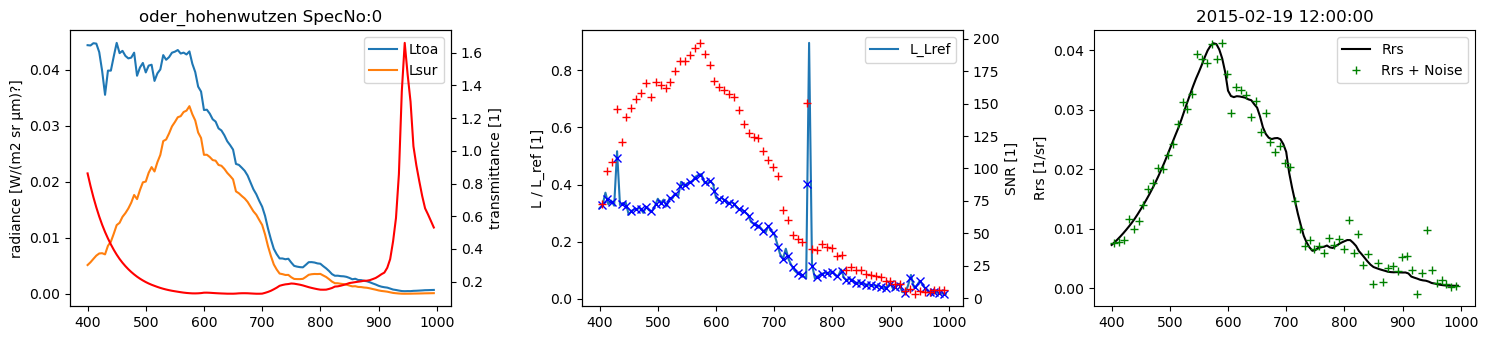

In [29]:
ispec = 0

fig, ax = plt.subplots(ncols=3, figsize=(15,3.5))
ax[0].plot(wl, Ltoa.iloc[ispec,:], '-', label='Ltoa')
ax[0].plot(wl, Lsur.iloc[ispec,:], '-', label='Lsur')
if ispec == 432 and regionName=='Helsinki_FM':
    ax[0].plot(wavelengths_olci, olci[bandStrOLCI].iloc[0,:]/1000., 'o', color='grey', alpha=0.6, label='OLCI Ltoa')
# ax[0].plot(wl, Rrs.iloc[ispec,:], '-', label='Rrs')
ax[0].set_ylabel('radiance [W/(m2 sr µm)?]')
ax[0].legend()
ax[0].set_title(regionName + ' SpecNo:' + str(int(ispec)))
ax1 = ax[0].twinx()
ax1.plot(wl, t_tot.iloc[ispec,:], 'r-')
ax1.set_ylabel('transmittance [1]')


ax[1].plot(wl, L_Lref.iloc[ispec,:], '-', label='L_Lref')
ax[1].plot(wl_, L_Lref_CHIME[ispec], 'x', color='blue')
ax[1].set_ylabel('L / L_ref [1]')
ax[1].legend()


ax2 = ax[1].twinx()
ax2.plot(wl_, snrArr[ispec,:], 'r+')
ax2.set_ylabel('SNR [1]')

# ax[2].plot(wl, Lsur.iloc[0,:].values, '-', label='Lsur')
# ax[2].plot(wl_, Lsur_CHIME[0,:] + noise_water[0,:], '+')
# ax[2].set_ylabel('radiance [W/(m2 sr µm)?]')

# ax3 = ax[2].twinx()
ax[2].plot(wl, Rrs_test.iloc[ispec,:], 'k-', label='Rrs')
ax[2].plot(wl_, Rrs_noise[ispec,:], 'g+', label='Rrs + Noise')
# ax[2].plot(wl, Rrs.iloc[ispec,:], '-', label='Rrs precalculated')
# ax[2].plot(wl_fw, forward.iloc[ispec,:], '--', color='aqua', label='BC Bi&Hi')

if regionName == 'vortsjarv':
    if Rrs.index[ispec] in insituRrs.index:
        ax[2].plot(wl_ins, insituRrs.loc[Rrs.index[ispec],:], '-', label='insitu')

ax[2].set_title(str(Rrs.index[ispec]))
    
ax[2].set_ylabel('Rrs [1/sr]')
ax[2].legend()
fig.tight_layout()
plt.show()


In [30]:
## overview noise in Rrs in %
noise_perc = np.abs((Rrs_noise - Rrs_CHIME)/Rrs_CHIME*100.)

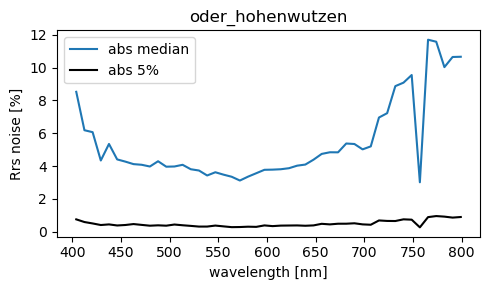

In [31]:
ID = wl_ < 800
fig, ax =plt.subplots(figsize=(5,3))
ax.plot(wl_[ID], np.median(noise_perc, axis=0)[ID], '-', label='abs median')
ax.plot(wl_[ID], np.percentile(noise_perc, 5, axis=0)[ID], '-', color='black', label='abs 5%')
# ax.plot(wl_[ID], np.percentile(noise_perc, 95, axis=0)[ID], '-', color='grey', label='abs 95%')
ax.legend()
ax.set_title(regionName)
ax.set_ylabel('Rrs noise [%]')
ax.set_xlabel('wavelength [nm]')
fig.tight_layout()
plt.show()

In [ ]:
### write 